# Road Accident Risk Prediction
1. Data Import and Basic Inspection
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training and Comparison-CatBoost
5. Final Prediction


## 1. Data Import and Basic Inspection


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Progress bar library
from tqdm.auto import tqdm
import time

# Set font and graphics style
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")


In [3]:
# Read data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Display first 5 rows of training set
print("\nFirst 5 rows of training set:")
train_df.head()



First 5 rows of training set:


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


## 2. Exploratory Data Analysis (EDA)


In [4]:
# Basic data information
print("Training set information:")
print(train_df.info())
print(f"\nMissing values:")
print(train_df.isnull().sum())

print(f"\nTest set missing values:")
print(test_df.isnull().sum())

print(f"\nTraining set target variable statistics:")
print(train_df['accident_risk'].describe())


Training set information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64

- mean: 0.352377    
- std: 0.166417     
- min: 0.000000    
- max: 1.000000    

- numeric: 4 (id, num_lanes, speed_limit, num_reported_accidents)
- float: 2 (curvature, accident_risk)


- categorical: 4 (road_type, lighting, weather, time_of_day)
- Boolean: 4 (road_signs_present, public_road, holiday, school_season)

### Numerical Features Analysis

Detailed Distribution Analysis for Numerical Features


<Figure size 1200x800 with 0 Axes>

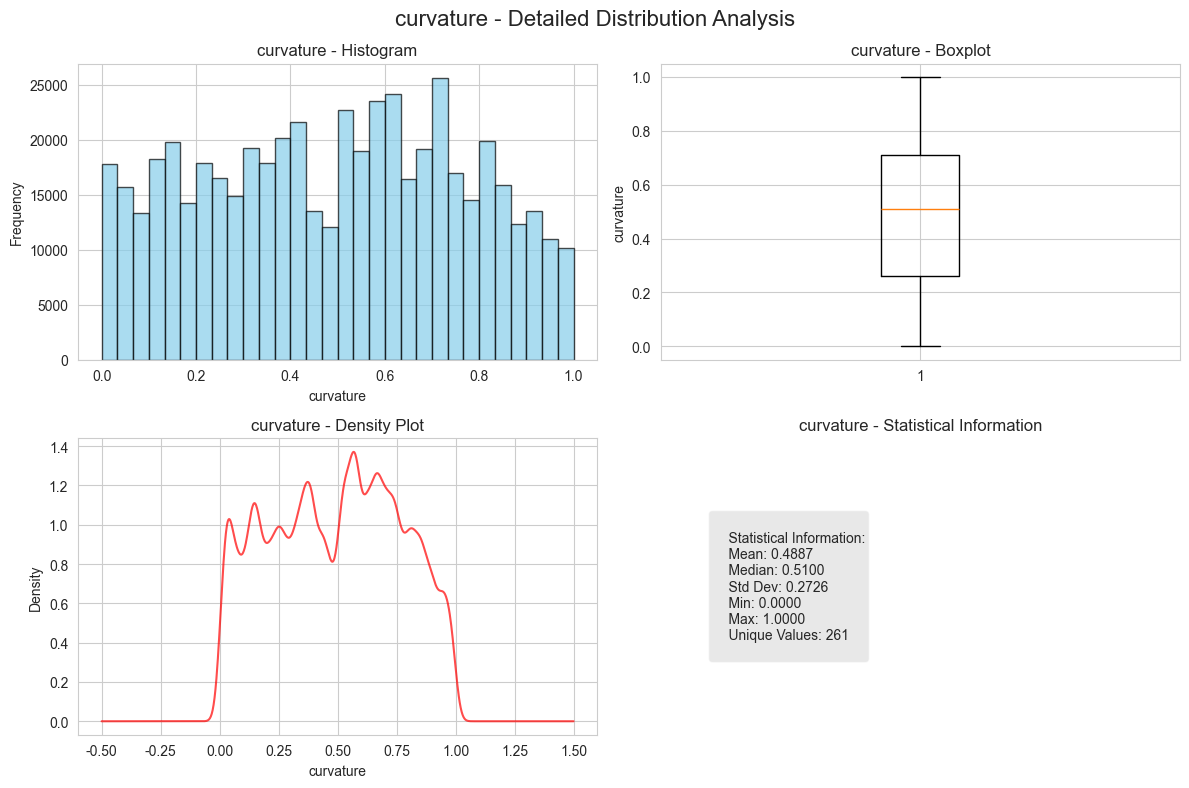


curvature Feature Analysis:
  Data Type: float64
  Missing Values: 0
  Unique Values: 261
  Distribution Shape: Continuous
--------------------------------------------------


<Figure size 1200x800 with 0 Axes>

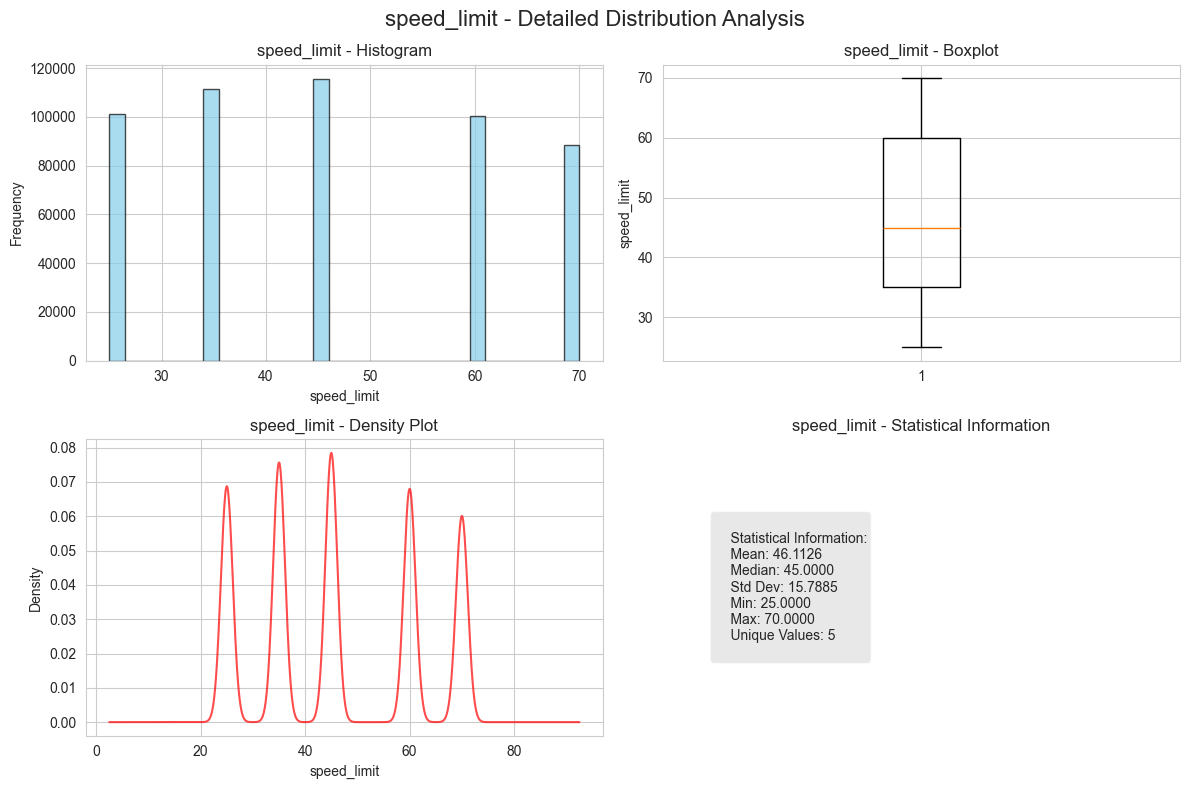


speed_limit Feature Analysis:
  Data Type: int64
  Missing Values: 0
  Unique Values: 5
  Distribution Shape: Multi-peak
  Unique Values: [np.int64(25), np.int64(35), np.int64(45), np.int64(60), np.int64(70)]
  Value Distribution:
    25: 101422 (19.6%)
    35: 111628 (21.6%)
    45: 115752 (22.4%)
    60: 100304 (19.4%)
    70: 88648 (17.1%)
--------------------------------------------------


<Figure size 1200x800 with 0 Axes>

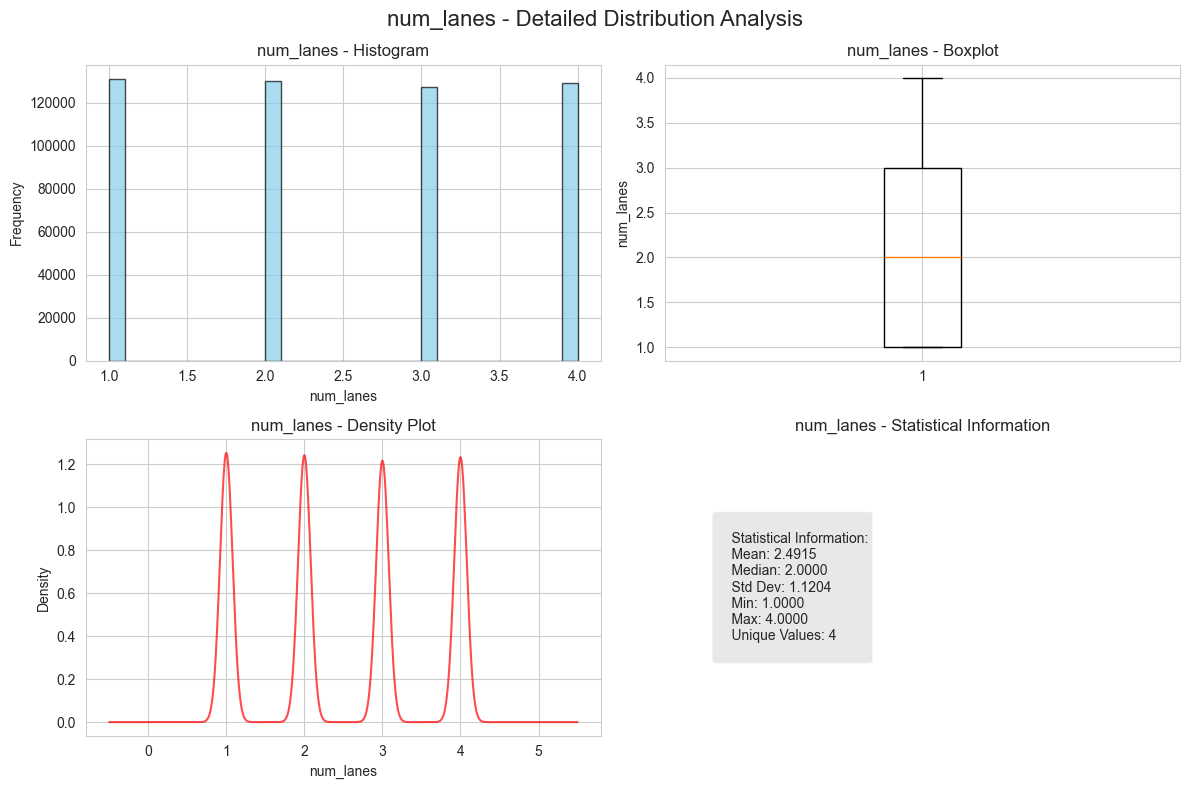


num_lanes Feature Analysis:
  Data Type: int64
  Missing Values: 0
  Unique Values: 4
  Distribution Shape: Multi-peak
  Unique Values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Value Distribution:
    1: 131168 (25.3%)
    2: 130054 (25.1%)
    3: 127414 (24.6%)
    4: 129118 (24.9%)
--------------------------------------------------


<Figure size 1200x800 with 0 Axes>

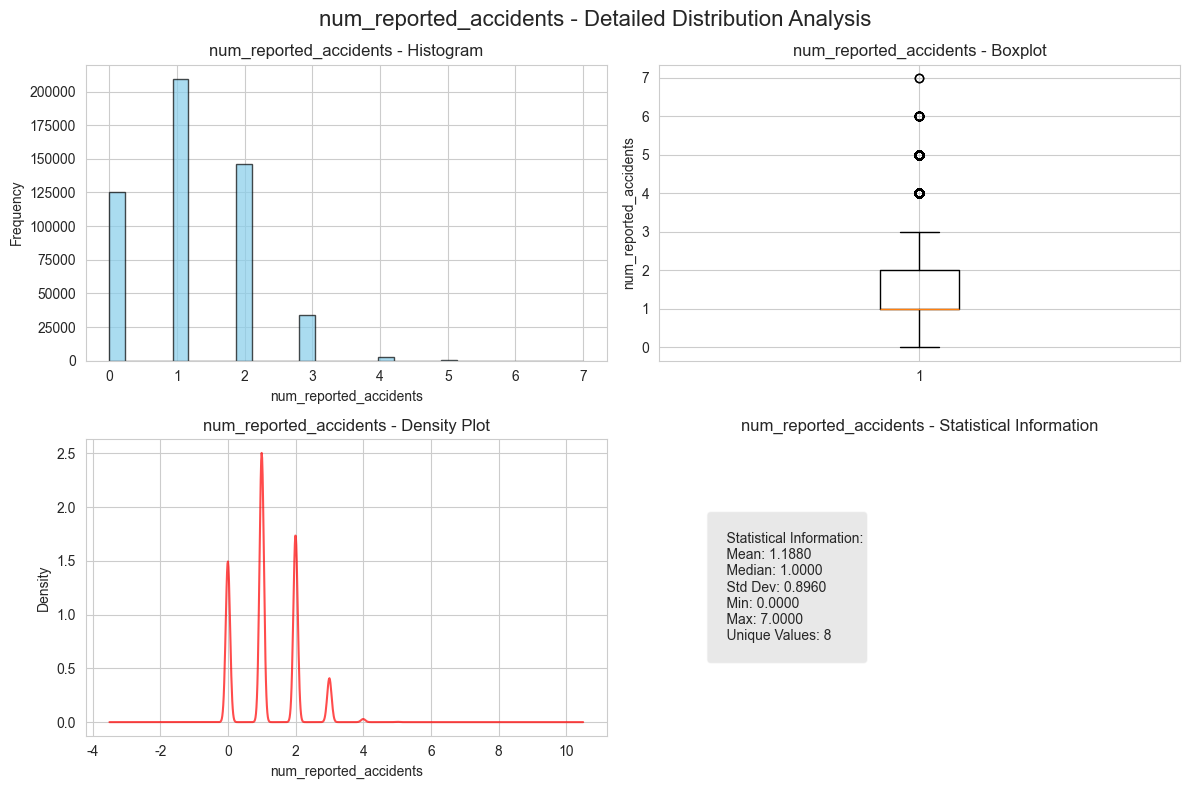


num_reported_accidents Feature Analysis:
  Data Type: int64
  Missing Values: 0
  Unique Values: 8
  Distribution Shape: Multi-peak
  Unique Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  Value Distribution:
    0: 125269 (24.2%)
    1: 209674 (40.5%)
    2: 145965 (28.2%)
    3: 34197 (6.6%)
    4: 2392 (0.5%)
    5: 231 (0.0%)
    6: 24 (0.0%)
    7: 2 (0.0%)
--------------------------------------------------


In [5]:
# Create detailed analysis plots for each numerical feature
print("="*60)
print("Detailed Distribution Analysis for Numerical Features")
print("="*60)

numeric_features = ['curvature', 'speed_limit', 'num_lanes', 'num_reported_accidents']

for feature in numeric_features:
    plt.figure(figsize=(12, 8))
    
    # Create 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{feature} - Detailed Distribution Analysis', fontsize=16)
    
    # 1. Histogram
    axes[0,0].hist(train_df[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0,0].set_title(f'{feature} - Histogram')
    axes[0,0].set_xlabel(feature)
    axes[0,0].set_ylabel('Frequency')
    
    # 2. Boxplot
    axes[0,1].boxplot(train_df[feature])
    axes[0,1].set_title(f'{feature} - Boxplot')
    axes[0,1].set_ylabel(feature)
    
    # 3. Density plot
    train_df[feature].plot.density(ax=axes[1,0], color='red', alpha=0.7)
    axes[1,0].set_title(f'{feature} - Density Plot')
    axes[1,0].set_xlabel(feature)
    axes[1,0].set_ylabel('Density')
    
    # 4. Statistical information
    stats_text = f"""
    Statistical Information:
    Mean: {train_df[feature].mean():.4f}
    Median: {train_df[feature].median():.4f}
    Std Dev: {train_df[feature].std():.4f}
    Min: {train_df[feature].min():.4f}
    Max: {train_df[feature].max():.4f}
    Unique Values: {train_df[feature].nunique()}
    """
    axes[1,1].text(0.1, 0.5, stats_text, transform=axes[1,1].transAxes, 
                   fontsize=10, verticalalignment='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))
    axes[1,1].set_title(f'{feature} - Statistical Information')
    axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print feature analysis
    print(f"\n{feature} Feature Analysis:")
    print(f"  Data Type: {train_df[feature].dtype}")
    print(f"  Missing Values: {train_df[feature].isnull().sum()}")
    print(f"  Unique Values: {train_df[feature].nunique()}")
    print(f"  Distribution Shape: {'Multi-peak' if train_df[feature].nunique() <= 10 else 'Continuous'}")
    
    if train_df[feature].nunique() <= 10:
        print(f"  Unique Values: {sorted(train_df[feature].unique())}")
        print(f"  Value Distribution:")
        for value, count in train_df[feature].value_counts().sort_index().items():
            print(f"    {value}: {count} ({count/len(train_df)*100:.1f}%)")
    
    print("-" * 50)


In [6]:
def process_numerical_features(train_df, test_df):

    train_processed = train_df.copy()
    test_processed = test_df.copy()
    
    # 1. curvature 
    def curvature_peak_classification(curvature):
        if 0.05 <= curvature <= 0.1:
            return 'straight_road'
        elif 0.15 <= curvature <= 0.2:
            return 'gentle_curve'
        elif 0.35 <= curvature <= 0.4:
            return 'moderate_curve'
        elif 0.5 <= curvature <= 0.6:
            return 'sharp_curve'
        elif 0.65 <= curvature <= 0.75:
            return 'very_sharp_curve'
        else:
            return 'other_curve'
    
    # 2. speed_limit 
    def speed_risk_level(speed):
        if speed <= 40:
            return 'low_risk'
        elif speed <= 50:
            return 'medium_risk'
        elif speed <= 60:
            return 'high_risk'
        else:
            return 'very_high_risk'
    
    train_processed['curvature_category'] = train_processed['curvature'].apply(curvature_peak_classification)
    train_processed['speed_risk_level'] = train_processed['speed_limit'].apply(speed_risk_level)
    
    test_processed['curvature_category'] = test_processed['curvature'].apply(curvature_peak_classification)
    test_processed['speed_risk_level'] = test_processed['speed_limit'].apply(speed_risk_level)
    
    categorical_features = ['curvature_category', 'speed_risk_level']
    le_dict = {}
    
    for feature in categorical_features:
        le = LabelEncoder()
        train_processed[feature] = le.fit_transform(train_processed[feature])
        le_dict[feature] = le
    

    for feature in categorical_features:
        le = le_dict[feature]
        test_processed[feature] = le.transform(test_processed[feature])
    
    return train_processed, test_processed, le_dict

train_processed, test_processed, le_dict = process_numerical_features(train_df, test_df)

### Categorical Feature Analysis


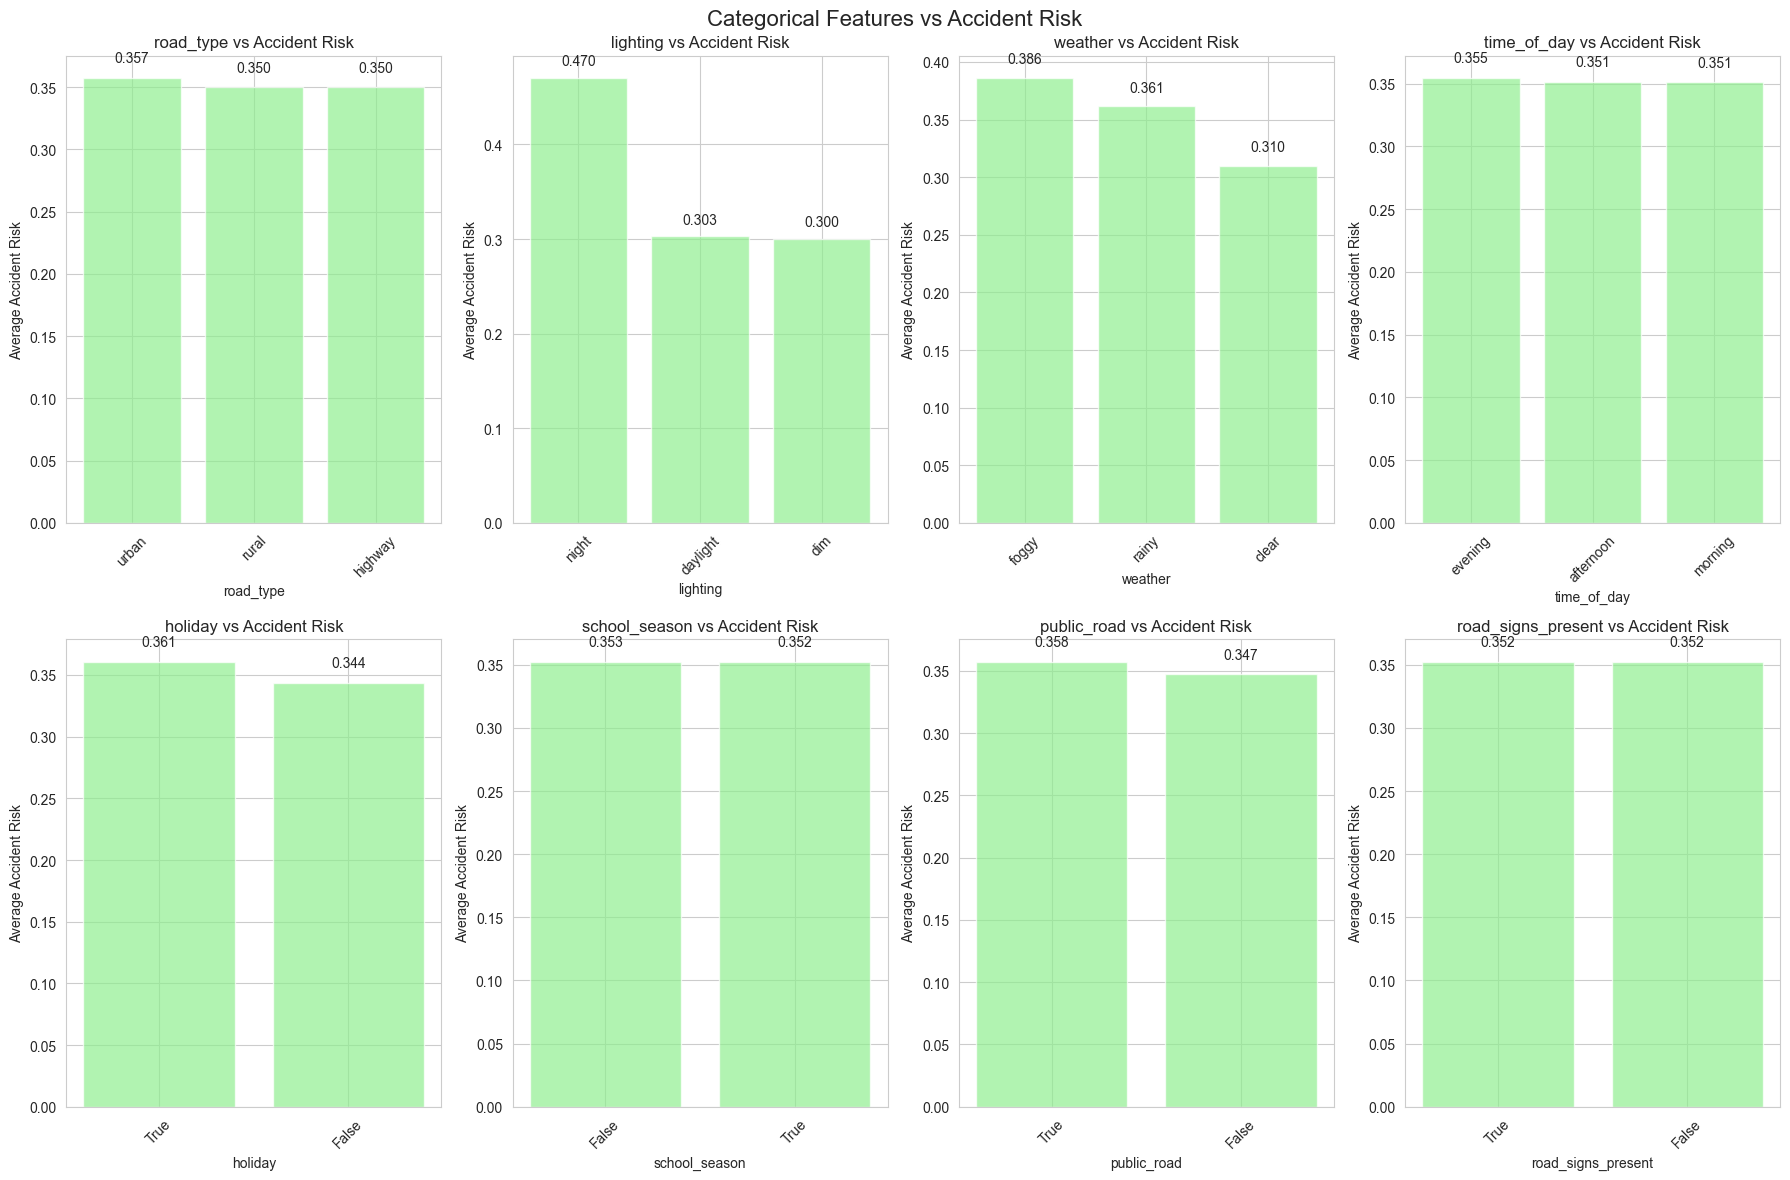

In [7]:
# Categorical features vs accident risk analysis
categorical_features = ['road_type', 'lighting', 'weather', 'time_of_day', 'holiday', 'school_season','public_road','road_signs_present']

fig, axes = plt.subplots(2, 4, figsize=(18, 12))
fig.suptitle('Categorical Features vs Accident Risk', fontsize=16)

for i, feature in enumerate(categorical_features):
    row = i // 4
    col = i % 4
    
    # Calculate average accident risk for each category
    feature_risk = train_df.groupby(feature)['accident_risk'].mean().sort_values(ascending=False)
    
    axes[row, col].bar(range(len(feature_risk)), feature_risk.values, color='lightgreen', alpha=0.7)
    axes[row, col].set_title(f'{feature} vs Accident Risk')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Average Accident Risk')
    axes[row, col].set_xticks(range(len(feature_risk)))
    axes[row, col].set_xticklabels(feature_risk.index, rotation=45)
    
    # Add numerical labels
    for j, v in enumerate(feature_risk.values):
        axes[row, col].text(j, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


- Relationship between 6 categorical features and accident risk
#### High Impact
1. lighting (Lighting conditions)
- night: 0.470 (highest risk)
- daylight: 0.303
- dim: 0.300
- Type: Ordered
- Order: night > dim > daylight
- Ordinal Encoding

2. weather (Weather)
- foggy: 0.386 (highest risk)
- rainy: 0.361
- clear: 0.310
- Type: Ordered
- Order: foggy > rainy > clear
- Ordinal Encoding

#### Medium
3. holiday (Holiday)
- True: 0.361
- False: 0.344
- Type: Binary
- Categories: True / False
- Label Encoding

4. public_road (Public road status)
- True: 0.358
- False: 0.347
- Type: Binary
- Categories: True / False
- Label Encoding


#### Low
5. road_type (Road type)
- urban: 0.357
- rural: 0.350
- highway: 0.350
- Type: Unordered
- Categories: urban, rural, highway
- One-Hot Encoding

6. time_of_day (Time of day)
- evening: 0.355
- afternoon: 0.351
- morning: 0.351
- Order: evening > afternoon ≈ morning
- Ordinal Encoding

7. school_season (School season)
- False: 0.353
- True: 0.352
- Categories: True / False
- Label Encoding


8. road_signs_present (Road signs presence)
- True: 0.352
- False: 0.352
- Type: Binary
- Categories: True / False
- Label Encoding

In [8]:
def encode_features(train_df, test_df):
    train_processed = train_df.copy()
    test_processed = test_df.copy()
    
    # High impact - ordinal encoding
    lighting_map = {'dim': 1, 'daylight': 2, 'night': 3}
    weather_map = {'clear': 1, 'rainy': 2, 'foggy': 3}
    time_map = {'morning': 1, 'afternoon': 2, 'evening': 3}
    
    train_processed['lighting_risk'] = train_processed['lighting'].map(lighting_map)
    test_processed['lighting_risk'] = test_processed['lighting'].map(lighting_map)
    train_processed['weather_risk'] = train_processed['weather'].map(weather_map)
    test_processed['weather_risk'] = test_processed['weather'].map(weather_map)
    train_processed['time_risk'] = train_processed['time_of_day'].map(time_map)
    test_processed['time_risk'] = test_processed['time_of_day'].map(time_map)
    
    # Medium impact - binary encoding
    train_processed['holiday_risk'] = train_processed['holiday'].astype(int)
    test_processed['holiday_risk'] = test_processed['holiday'].astype(int)
    train_processed['public_road_risk'] = train_processed['public_road'].astype(int)
    test_processed['public_road_risk'] = test_processed['public_road'].astype(int)
    
    # Low impact - one-hot encoding
    road_type_dummies_train = pd.get_dummies(train_processed['road_type'], prefix='road_type')
    road_type_dummies_test = pd.get_dummies(test_processed['road_type'], prefix='road_type')
    for col in road_type_dummies_train.columns:
        if col not in road_type_dummies_test.columns:
            road_type_dummies_test[col] = 0
    train_processed = pd.concat([train_processed, road_type_dummies_train], axis=1)
    test_processed = pd.concat([test_processed, road_type_dummies_test], axis=1)
    
    train_processed['school_risk'] = train_processed['school_season'].astype(int)
    test_processed['school_risk'] = test_processed['school_season'].astype(int)
    train_processed['road_signs_risk'] = train_processed['road_signs_present'].astype(int)
    test_processed['road_signs_risk'] = test_processed['road_signs_present'].astype(int)
    
    # Drop original categorical columns
    cat_cols = ['road_type', 'lighting', 'weather', 'time_of_day', 
                'holiday', 'school_season', 'public_road', 'road_signs_present']
    train_processed = train_processed.drop(columns=cat_cols)
    test_processed = test_processed.drop(columns=cat_cols)
    
    return train_processed, test_processed

# Execute encoding
train_encoded, test_encoded = encode_features(train_df, test_df)
print(f"Train: {train_encoded.shape}, Test: {test_encoded.shape}")


Train: (517754, 16), Test: (172585, 15)


## 3. Feature Engineering


Feature correlations with accident_risk:
 1. curvature                  0.5439
 2. speed_limit                0.4309
 3. lighting_risk              0.4023
 4. num_reported_accidents     0.2139
 5. weather_risk               0.1911
 6. holiday_risk               0.0511
 7. public_road_risk           0.0310
 8. road_type_urban            0.0215
 9. road_type_highway         -0.0113
10. road_type_rural           -0.0101
11. time_risk                  0.0093
12. num_lanes                 -0.0060
13. school_risk               -0.0010
14. road_signs_risk            0.0006


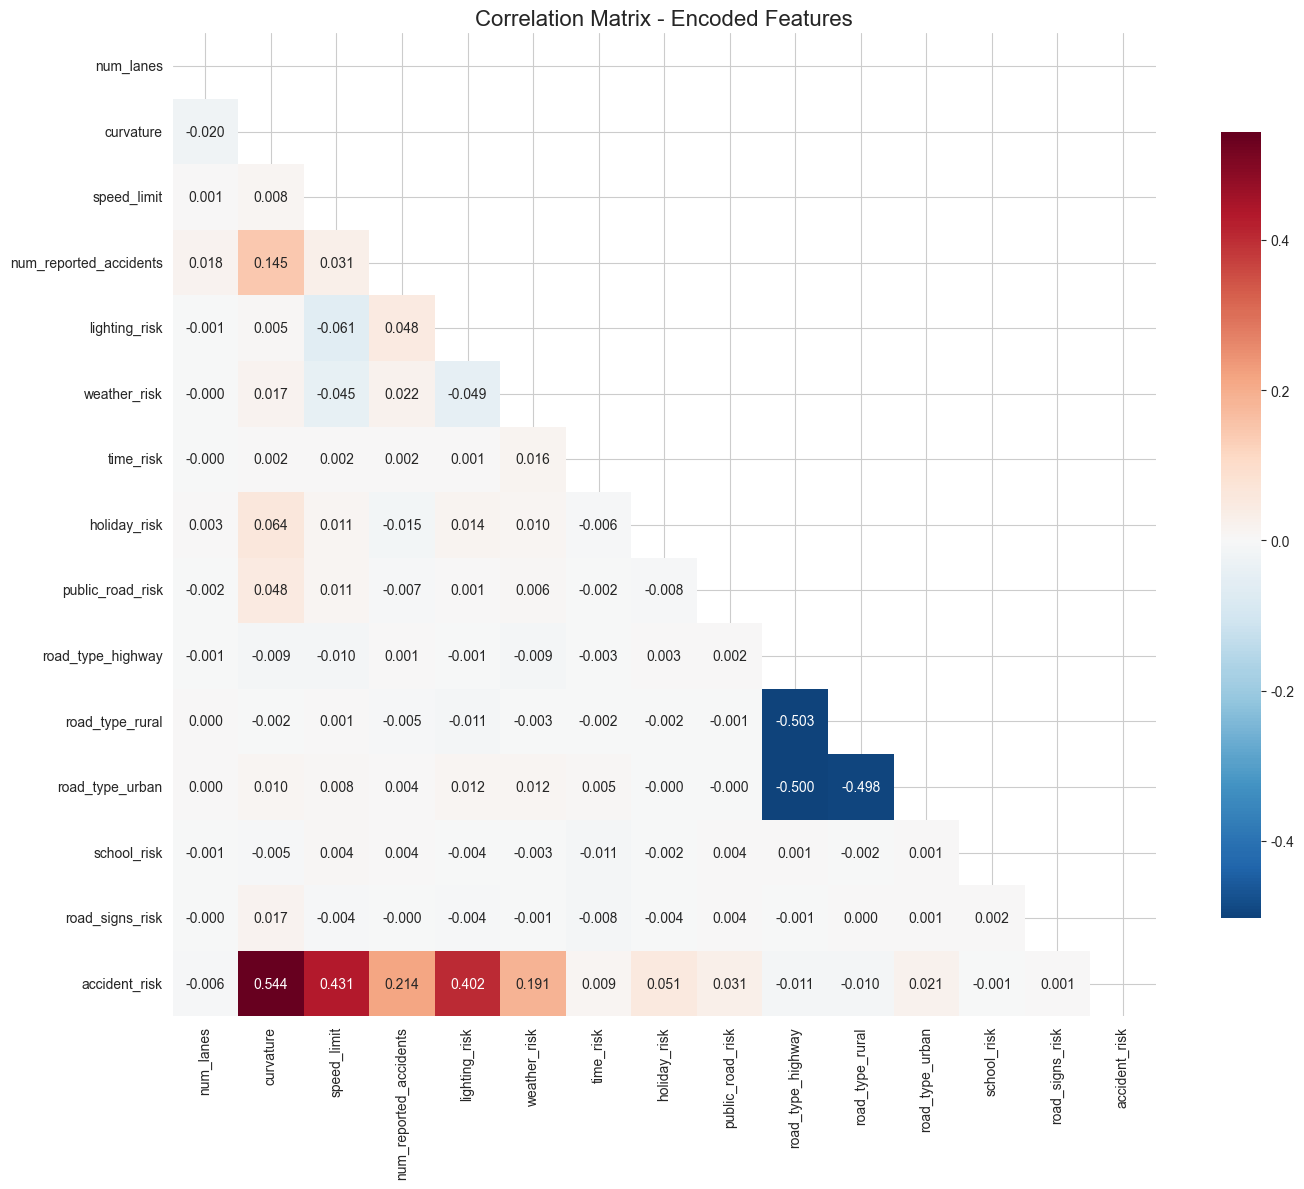


High correlation features (>0.1): 5
  curvature                  0.5439
  speed_limit                0.4309
  lighting_risk              0.4023
  num_reported_accidents     0.2139
  weather_risk               0.1911


In [9]:
# Correlation analysis with encoded features
X = train_encoded.drop(['id', 'accident_risk'], axis=1)
y = train_encoded['accident_risk']

correlation_data = X.copy()
correlation_data['accident_risk'] = y

correlation_matrix = correlation_data.corr()
target_correlations = correlation_matrix['accident_risk'].drop('accident_risk').abs().sort_values(ascending=False)

print("Feature correlations with accident_risk:")
for i, (feature, corr) in enumerate(target_correlations.items(), 1):
    actual_corr = correlation_matrix['accident_risk'][feature]
    print(f"{i:2d}. {feature:<25} {actual_corr:>7.4f}")

# Visualization
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix - Encoded Features', fontsize=16)
plt.tight_layout()
plt.show()

# High correlation features
high_corr = target_correlations[target_correlations > 0.1]
print(f"\nHigh correlation features (>0.1): {len(high_corr)}")
for feature, corr in high_corr.items():
    actual_corr = correlation_matrix['accident_risk'][feature]
    print(f"  {feature:<25} {actual_corr:>7.4f}")


In [10]:
# Create interaction features
train_final = train_encoded.copy()
test_final = test_encoded.copy()

# High correlation interactions
train_final['curvature_speed'] = train_final['curvature'] * train_final['speed_limit']
test_final['curvature_speed'] = test_final['curvature'] * test_final['speed_limit']

train_final['curvature_lighting'] = train_final['curvature'] * train_final['lighting_risk']
test_final['curvature_lighting'] = test_final['curvature'] * test_final['lighting_risk']

train_final['speed_lighting'] = train_final['speed_limit'] * train_final['lighting_risk']
test_final['speed_lighting'] = test_final['speed_limit'] * test_final['lighting_risk']

# Weather interactions
train_final['weather_curvature'] = train_final['weather_risk'] * train_final['curvature']
test_final['weather_curvature'] = test_final['weather_risk'] * test_final['curvature']

train_final['weather_speed'] = train_final['weather_risk'] * train_final['speed_limit']
test_final['weather_speed'] = test_final['weather_risk'] * test_final['speed_limit']

# Risk combinations
train_final['high_risk_combo'] = ((train_final['lighting_risk'] >= 3) & (train_final['weather_risk'] >= 2)).astype(int)
test_final['high_risk_combo'] = ((test_final['lighting_risk'] >= 3) & (test_final['weather_risk'] >= 2)).astype(int)

print(f"Features: {train_encoded.shape[1]} -> {train_final.shape[1]}")
print(f"New interaction features: {train_final.shape[1] - train_encoded.shape[1]}")


Features: 16 -> 22
New interaction features: 6


## 4. Model Training and Validation

In [11]:
# Prepare modeling data
X = train_final.drop(['id', 'accident_risk'], axis=1)
y = train_final['accident_risk']
X_test = test_final.drop(['id'], axis=1)

print(f"Number of features: {X.shape[1]}")
print(f"Feature list: {list(X.columns)}")

# Split training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")


Number of features: 20
Feature list: ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents', 'lighting_risk', 'weather_risk', 'time_risk', 'holiday_risk', 'public_road_risk', 'road_type_highway', 'road_type_rural', 'road_type_urban', 'school_risk', 'road_signs_risk', 'curvature_speed', 'curvature_lighting', 'speed_lighting', 'weather_curvature', 'weather_speed', 'high_risk_combo']
Training set size: 414203
Validation set size: 103551


In [12]:
# Define evaluation function
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    """Evaluate model performance"""
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    train_r2 = r2_score(y_train, y_pred_train)
    val_r2 = r2_score(y_val, y_pred_val)
    
    print(f"\n{model_name} Performance:")
    print(f"Training RMSE: {train_rmse:.6f}")
    print(f"Validation RMSE: {val_rmse:.6f}")
    print(f"Training R²: {train_r2:.6f}")
    print(f"Validation R²: {val_r2:.6f}")
    
    return model, val_rmse, y_pred_val


### 4.1 Baseline Model Comparison


In [13]:
# Define baseline models
models = {
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        random_state=42,
        verbose=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        verbosity=0
    ),
    'CatBoost': CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=False
    )
}

model_results = {}
for name, model in models.items():
    trained_model, rmse, predictions = evaluate_model(model, X_train, y_train, X_val, y_val, name)
    model_results[name] = {
        'model': trained_model, 
        'rmse': rmse, 
        'predictions': predictions
    }

# Find best model
best_model_name = min(model_results.keys(), key=lambda x: model_results[x]['rmse'])
print(f"\nBest Baseline Model: {best_model_name}")
print(f"Validation RMSE: {model_results[best_model_name]['rmse']:.6f}")



LightGBM Performance:
Training RMSE: 0.054731
Validation RMSE: 0.056295
Training R²: 0.891917
Validation R²: 0.885228

XGBoost Performance:
Training RMSE: 0.053802
Validation RMSE: 0.056460
Training R²: 0.895556
Validation R²: 0.884552

CatBoost Performance:
Training RMSE: 0.055291
Validation RMSE: 0.056197
Training R²: 0.889695
Validation R²: 0.885625

Best Baseline Model: CatBoost
Validation RMSE: 0.056197


### 4.2 Cross Validation-Optimal Fold


In [14]:
# Compare different CV folds to find optimal
def compare_cv_folds(X, y, model_results, cv_folds=[3, 5, 7, 10, 15]):
    """Compare different CV folds to find optimal"""
    
    print("CROSS VALIDATION FOLDS COMPARISON")
    
    results = {}
    
    for n_folds in cv_folds:
        print(f"\n{n_folds}-Fold Cross Validation:")
        
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
        fold_results = {}
        model = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.1,
            depth=6,
            random_seed=42,
            verbose=False
        )
        
        cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
        cv_rmse = np.sqrt(-cv_scores)
        
        results[n_folds] = {
            'mean_rmse': cv_rmse.mean(),
            'std_rmse': cv_rmse.std(),
            'min_rmse': cv_rmse.min(),
            'max_rmse': cv_rmse.max()
        }
            
        print(f"CatBoost: {cv_rmse.mean():.6f} ± {cv_rmse.std():.6f}")
        
        results[n_folds] = fold_results
    
    return results

# Run comparison
cv_comparison = compare_cv_folds(X, y, model_results)

# Find best CV fold for each model
print("OPTIMAL CV FOLDS ANALYSIS")

cv_folds = list(range(5, 16))


CROSS VALIDATION FOLDS COMPARISON

3-Fold Cross Validation:
CatBoost: 0.056085 ± 0.000124

5-Fold Cross Validation:
CatBoost: 0.056043 ± 0.000112

7-Fold Cross Validation:
CatBoost: 0.056046 ± 0.000225

10-Fold Cross Validation:
CatBoost: 0.056029 ± 0.000216

15-Fold Cross Validation:
CatBoost: 0.056030 ± 0.000321
OPTIMAL CV FOLDS ANALYSIS


In [16]:
# CatBoost Optuna Hyperparameter Optimization (Fixed Parameter Range Version)
import optuna
print("Using Optuna for CatBoost hyperparameter optimization...")

def objective(trial):
    """Optuna objective function - only for CatBoost"""
    params = {
        'iterations': trial.suggest_int('iterations', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.1, 0.2),
        'depth': trial.suggest_int('depth', 6,8),
        'subsample': trial.suggest_float('subsample', 0.9, 1.0),  
        'reg_lambda': trial.suggest_float('reg_lambda', 0.3, 0.4),
        'random_seed': 42,
        'verbose': False
    }
    model = CatBoostRegressor(**params)
    
    # Use cross validation evaluation (reduced to 10-fold for speed)
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    return scores.mean()

# Create Optuna study
study = optuna.create_study(direction='maximize')

# Start optimization (reduced number of trials)
n_trials = 100
print(f"Optuna will conduct {n_trials} trials...")
print(f"Total computation: {n_trials} × 5 = {n_trials * 5} model training sessions")
start_time = time.time()

# Use Optuna directly without tqdm wrapper
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

end_time = time.time()
print(f"\nOptuna optimization completed! Time taken: {end_time - start_time:.2f} seconds")

print(f"\nOptuna best parameters: {study.best_params}")
print(f"Optuna best score: {study.best_value:.6f}")
print(f"Optuna best cross validation RMSE: {np.sqrt(-study.best_value):.6f}")

# Get top 10 best trials
print(f"\n" + "="*60)
print("Top 10 Best Parameter Combinations")
print("="*60)

# Get all trials sorted by value (best first)
trials_df = study.trials_dataframe()
trials_df_sorted = trials_df.sort_values('value', ascending=False).head(10)

print("Top 10 best parameter combinations:")
for i, (idx, row) in enumerate(trials_df_sorted.iterrows(), 1):
    rmse = np.sqrt(-row['value'])
    print(f"\n{i:2d}. Trial {row['number']:3d} - RMSE: {rmse:.6f}")
    print(f"    Parameters:")
    for param in ['iterations', 'learning_rate', 'depth', 'subsample', 'reg_lambda']:
        if f'params_{param}' in row:
            print(f"      {param}: {row[f'params_{param}']:.6f}")

# Save top 10 results to CSV
top_10_results = trials_df_sorted[['number', 'value'] + [col for col in trials_df_sorted.columns if col.startswith('params_')]].copy()
top_10_results['rmse'] = np.sqrt(-top_10_results['value'])
top_10_results = top_10_results.drop('value', axis=1)
top_10_results.to_csv('optuna_top_10_results.csv', index=False)

print(f"\n Top 10 results saved to 'optuna_top_10_results.csv'")

# Use best parameters to train model
optuna_model = CatBoostRegressor(**study.best_params, random_seed=42, verbose=False)

optuna_model.fit(X_train, y_train)
y_pred_optuna = optuna_model.predict(X_val)
optuna_rmse = np.sqrt(mean_squared_error(y_val, y_pred_optuna))

print(f"\nOptuna validation RMSE: {optuna_rmse:.6f}")

# Compare with baseline model
if 'model_results' in locals():
    baseline_rmse = min([result['rmse'] for result in model_results.values()])
    optuna_improvement = (baseline_rmse - optuna_rmse) / baseline_rmse * 100
    print(f"Optuna improvement over baseline: {optuna_improvement:.2f}%")
else:
    print("No baseline model for comparison")

[I 2025-10-05 17:08:26,772] A new study created in memory with name: no-name-80316072-9337-4931-b281-aacf3bca1ba0


Using Optuna for CatBoost hyperparameter optimization...
Optuna will conduct 100 trials...
Total computation: 100 × 5 = 500 model training sessions


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-10-05 17:08:40,845] Trial 0 finished with value: -0.0031493582741697473 and parameters: {'iterations': 222, 'learning_rate': 0.14517042819733014, 'depth': 8, 'subsample': 0.9474553632437152, 'reg_lambda': 0.3258593180727549}. Best is trial 0 with value: -0.0031493582741697473.
[I 2025-10-05 17:08:55,492] Trial 1 finished with value: -0.003145879118761032 and parameters: {'iterations': 340, 'learning_rate': 0.16960452449753932, 'depth': 6, 'subsample': 0.9636255797346649, 'reg_lambda': 0.3208000949836532}. Best is trial 1 with value: -0.003145879118761032.
[I 2025-10-05 17:09:03,739] Trial 2 finished with value: -0.0031644603510934065 and parameters: {'iterations': 195, 'learning_rate': 0.11368131856842467, 'depth': 6, 'subsample': 0.9405916270007264, 'reg_lambda': 0.338385496021772}. Best is trial 1 with value: -0.003145879118761032.
[I 2025-10-05 17:09:14,659] Trial 3 finished with value: -0.003151632594038444 and parameters: {'iterations': 249, 'learning_rate': 0.181532793978

In [17]:
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_parallel_coordinate(study)
fig.show()

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

random_params = {
    'iterations': randint(420, 520),          
    'learning_rate': uniform(0.12, 0.16),       
    'depth': [6],                              
    'subsample': uniform(0.95, 1.0),           
    'reg_lambda': uniform(0.28, 0.35)         
}

n_iter = 150
print(f"Random Search will try {n_iter} random parameter combinations")

random_search = RandomizedSearchCV(
    CatBoostRegressor(random_seed=42, verbose=False),
    random_params,
    n_iter=n_iter,
    cv=10,  
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting Random Search...")
start_time = time.time()
random_search.fit(X_train, y_train)
end_time = time.time()

print(f"\nRandom Search completed! Time taken: {end_time - start_time:.2f} seconds")
print(f"Random Search best parameters: {random_search.best_params_}")
print(f"Random Search best cross-validation RMSE: {np.sqrt(-random_search.best_score_):.6f}")


results_df = pd.DataFrame(random_search.cv_results_)
results_sorted = results_df.sort_values('mean_test_score', ascending=False).head(5)

print("Top 5 best parameter combinations:")
for i, (idx, row) in enumerate(results_sorted.iterrows(), 1):
    rmse = np.sqrt(-row['mean_test_score'])
    rmse_std = np.sqrt(row['std_test_score'])
    print(f"\n{i:2d}. RMSE: {rmse:.6f} (±{rmse_std:.6f})")
    print(f"    Parameters:")
    for param in ['iterations', 'learning_rate', 'subsample', 'reg_lambda']:
        if f'param_{param}' in row:
            print(f"      {param}: {row[f'param_{param}']:.6f}")

top_5_results = results_sorted[['mean_test_score', 'std_test_score'] + [col for col in results_sorted.columns if col.startswith('param_')]].copy()
top_5_results['rmse'] = np.sqrt(-top_5_results['mean_test_score'])
top_5_results['rmse_std'] = np.sqrt(top_5_results['std_test_score'])
top_5_results = top_5_results.drop(['mean_test_score', 'std_test_score'], axis=1)
top_5_results.to_csv('random_search_top_5_results.csv', index=False)

print(f"\n Top 5 results saved to 'random_search_top_5_results.csv'")

print("Top 5 Results Summary")
print(f"Best RMSE: {np.sqrt(-results_sorted.iloc[0]['mean_test_score']):.6f}")
print(f"Worst RMSE (in top 5): {np.sqrt(-results_sorted.iloc[4]['mean_test_score']):.6f}")
print(f"Average RMSE (top 5): {np.sqrt(-results_sorted['mean_test_score']).mean():.6f}")


Random Search will try 150 random parameter combinations
Starting Random Search...
Fitting 10 folds for each of 150 candidates, totalling 1500 fits

Random Search completed! Time taken: 736.67 seconds
Random Search best parameters: {'depth': 6, 'iterations': 509, 'learning_rate': np.float64(0.1577575871598329), 'reg_lambda': np.float64(0.3696239129664634), 'subsample': np.float64(0.9904335895384313)}
Random Search best cross-validation RMSE: 0.056056
Top 5 best parameter combinations:

 1. RMSE: 0.056056 (±0.005458)
    Parameters:
      iterations: 509.000000
      learning_rate: 0.157758
      subsample: 0.990434
      reg_lambda: 0.369624

 2. RMSE: 0.056058 (±0.005553)
    Parameters:
      iterations: 517.000000
      learning_rate: 0.135037
      subsample: 0.985942
      reg_lambda: 0.482398

 3. RMSE: 0.056064 (±0.005630)
    Parameters:
      iterations: 507.000000
      learning_rate: 0.183181
      subsample: 0.964080
      reg_lambda: 0.382721

 4. RMSE: 0.056068 (±0.005664

 1. RMSE: 0.056065 (±0.005690)
    Parameters:
      iterations: 443.000000
      learning_rate: 0.086092
      subsample: 0.977617
      reg_lambda: 0.648978

 2. RMSE: 0.056065 (±0.005545)
    Parameters:
      iterations: 340.000000
      learning_rate: 0.111194
      subsample: 0.982316
      reg_lambda: 0.453958

 3. RMSE: 0.056068 (±0.005614)
    Parameters:
      iterations: 397.000000
      learning_rate: 0.091278
      subsample: 0.985942
      reg_lambda: 0.510226

 4. RMSE: 0.056081 (±0.005724)
    Parameters:
      iterations: 340.000000
      learning_rate: 0.115553
      subsample: 0.965636
      reg_lambda: 0.324370

 5. RMSE: 0.056088 (±0.005635)
    Parameters:
      iterations: 326.000000
      learning_rate: 0.142728
      subsample: 0.975419
      reg_lambda: 0.442393

In [20]:
best_params = random_search.best_params_
print("Best Parameters:", best_params)

best_score = random_search.best_score_
print("Best Score:", best_score)

best_rmse = np.sqrt(-random_search.best_score_)
print("Best RMSE:", best_rmse)

Best Parameters: {'depth': 6, 'iterations': 509, 'learning_rate': np.float64(0.1577575871598329), 'reg_lambda': np.float64(0.3696239129664634), 'subsample': np.float64(0.9904335895384313)}
Best Score: -0.0031423262511075774
Best RMSE: 0.056056455927106


## 5. Final Prediction and Submission


In [24]:
# Retrain best model on all training data
best_model = CatBoostRegressor(**best_params, random_seed=42, verbose=False)
print("Retraining best model on all training data...")
best_model.fit(X, y)

# Generate test set predictions
print("Generating test set predictions...")
test_predictions = best_model.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'accident_risk': test_predictions
})

# Save submission file
submission.to_csv('submission.csv', index=False)

print(f"Prediction results saved to submission.csv")
print(f"Prediction value range: {test_predictions.min():.6f} - {test_predictions.max():.6f}")
print(f"Prediction statistics:")
print(f"  Mean: {test_predictions.mean():.6f}")
print(f"  Std: {test_predictions.std():.6f}")
print(f"  Median: {np.median(test_predictions):.6f}")

# Display first few rows of submission file
print(f"\nSubmission file preview:")
print(submission.head(10))


Retraining best model on all training data...
Generating test set predictions...
Prediction results saved to submission.csv
Prediction value range: -0.006030 - 0.875697
Prediction statistics:
  Mean: 0.351679
  Std: 0.156816
  Median: 0.337134

Submission file preview:
       id  accident_risk
0  517754       0.292542
1  517755       0.120771
2  517756       0.183034
3  517757       0.317042
4  517758       0.395821
5  517759       0.464062
6  517760       0.257022
7  517761       0.200228
8  517762       0.363234
9  517763       0.326378


# Feature Engineering

In [ ]:
# Create interaction features
train_final = train_encoded.copy()
test_final = test_encoded.copy()

# High correlation interactions
train_final['curvature_speed'] = train_final['curvature'] * train_final['speed_limit']
test_final['curvature_speed'] = test_final['curvature'] * test_final['speed_limit']

train_final['curvature_lighting'] = train_final['curvature'] * train_final['lighting_risk']
test_final['curvature_lighting'] = test_final['curvature'] * test_final['lighting_risk']

train_final['speed_lighting'] = train_final['speed_limit'] * train_final['lighting_risk']
test_final['speed_lighting'] = test_final['speed_limit'] * test_final['lighting_risk']

curvature_threshold = train_final['curvature'].quantile(0.75)  # 75%分位数
speed_threshold = train_final['speed_limit'].quantile(0.5)     # 50%分位数

lighting_high_risk = 3  
weather_bad = 2        
road_highway = 1  

train_final['extreme_risk'] = (
    (train_final['curvature'] > curvature_threshold) & 
    (train_final['lighting_risk'] >= lighting_high_risk) & 
    (train_final['weather_risk'] >= weather_bad)
).astype(int)

test_final['extreme_risk'] = (
    (test_final['curvature'] > curvature_threshold) & 
    (test_final['lighting_risk'] >= lighting_high_risk) & 
    (test_final['weather_risk'] >= weather_bad)
).astype(int)

train_final['moderate_risk'] = (
    (train_final['curvature'] > curvature_threshold) & 
    (train_final['lighting_risk'] >= lighting_high_risk) & 
    (train_final['weather_risk'] >= weather_bad)
).astype(int)

test_final['moderate_risk'] = (
    (test_final['curvature'] > curvature_threshold) & 
    (test_final['lighting_risk'] >= lighting_high_risk) & 
    (test_final['weather_risk'] >= weather_bad)
).astype(int)

train_final['low_risk'] = (
    (train_final['curvature'] <= curvature_threshold) & 
    (train_final['lighting_risk'] < lighting_high_risk) & 
    (train_final['weather_risk'] < weather_bad)
).astype(int)

test_final['low_risk'] = (
    (test_final['curvature'] <= curvature_threshold) & 
    (test_final['lighting_risk'] < lighting_high_risk) & 
    (test_final['weather_risk'] < weather_bad)
).astype(int)

# Moderate correlation interactions

train_final['curvature_accidents'] = train_final['curvature'] * train_final['num_reported_accidents']  # 0.544 × 0.214
test_final['curvature_accidents'] = test_final['curvature'] * test_final['num_reported_accidents']

train_final['speed_accidents'] = train_final['speed_limit'] * train_final['num_reported_accidents']  # 0.431 × 0.214
test_final['speed_accidents'] = test_final['speed_limit'] * test_final['num_reported_accidents']

train_final['lighting_accidents'] = train_final['lighting_risk'] * train_final['num_reported_accidents']  # 0.402 × 0.214
test_final['lighting_accidents'] = test_final['lighting_risk'] * test_final['num_reported_accidents']

# road_type interactions
road_type_risk_map = train_final.groupby('road_type')['accident_risk'].mean()
train_final['road_type_complexity'] = (
    train_final['road_type_highway'] * road_type_risk_map['highway'] + 
    train_final['road_type_rural'] * road_type_risk_map['rural'] + 
    train_final['road_type_urban'] * road_type_risk_map['urban']
)

test_final['road_type_complexity'] = (
    test_final['road_type_highway'] * road_type_risk_map['highway'] + 
    test_final['road_type_rural'] * road_type_risk_map['rural'] + 
    test_final['road_type_urban'] * road_type_risk_map['urban']
)   

# Weather interactions
train_final['weather_curvature'] = train_final['weather_risk'] * train_final['curvature']
test_final['weather_curvature'] = test_final['weather_risk'] * test_final['curvature']

train_final['weather_speed'] = train_final['weather_risk'] * train_final['speed_limit']
test_final['weather_speed'] = test_final['weather_risk'] * test_final['speed_limit']


# time_risk interactions
train_final['time_weather'] = train_final['time_risk'] * train_final['weather_risk']
test_final['time_weather'] = test_final['time_risk'] * test_final['weather_risk']

train_final['time_lighting'] = train_final['time_risk'] * train_final['lighting_risk']
test_final['time_lighting'] = test_final['time_risk'] * test_final['lighting_risk']

train_final['time_road_type'] = train_final['time_risk'] * train_final['road_type_complexity']
test_final['time_road_type'] = test_final['time_risk'] * test_final['road_type_complexity']



# Risk combinations
train_final['high_risk_combo'] = ((train_final['lighting_risk'] >= 3) & (train_final['weather_risk'] >= 2)).astype(int)
test_final['high_risk_combo'] = ((test_final['lighting_risk'] >= 3) & (test_final['weather_risk'] >= 2)).astype(int)

cat_cols = ['road_type']
train_final = train_final.drop(columns=cat_cols)
test_final = test_final.drop(columns=cat_cols)

print(f"Features: {train_encoded.shape[1]} -> {train_final.shape[1]}")
print(f"New interaction features: {train_final.shape[1] - train_encoded.shape[1]}")


In [ ]:
# Forward Selection Feature Selection with RMSE Stopping
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import time

def forward_selection_with_rmse_stopping(X_train, y_train, X_val, y_val, 
                                       min_improvement=0.0000001, max_features=20):
    """
    Forward selection with RMSE-based stopping criterion
    """
    print("Starting forward selection...")
    start_time = time.time()
    
    # Use CatBoost as base model with Random Search best parameters
    base_model = CatBoostRegressor(
        iterations=443,
        learning_rate=0.086092,
        depth=8,
        subsample=0.977617,
        reg_lambda=0.648978,
        random_seed=42,
        verbose=False
    )
    
    sfs = SequentialFeatureSelector(
        base_model,
        n_features_to_select=max_features,
        direction='forward',
        scoring='neg_mean_squared_error',
        cv=10,
        n_jobs=2
    )
    
    sfs.fit(X_train, y_train)
    all_selected_features = X_train.columns[sfs.get_support()].tolist()
    
    # Evaluate features step by step
    selected_features = []
    best_rmse = float('inf')
    
    for i in range(1, min(len(all_selected_features) + 1, max_features + 1)):
        current_features = all_selected_features[:i]
        X_train_current = X_train[current_features]
        X_val_current = X_val[current_features]
        
        # Use same CatBoost model for evaluation
        model = CatBoostRegressor(
            iterations=443,
            learning_rate=0.086092,
            depth=8,
            subsample=0.977617,
            reg_lambda=0.648978,
            random_seed=42,
            verbose=False
        )
        model.fit(X_train_current, y_train)
        y_pred = model.predict(X_val_current)
        current_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        
        if i == 1:
            best_rmse = current_rmse
            selected_features = current_features.copy()
        else:
            improvement = best_rmse - current_rmse
            if improvement > min_improvement:
                best_rmse = current_rmse
                selected_features = current_features.copy()
            else:
                break
    
    runtime = time.time() - start_time
    print(f"Forward selection completed in {runtime:.1f}s")
    print(f"Selected {len(selected_features)} features with RMSE: {best_rmse:.6f}")
    
    return selected_features, best_rmse

# Prepare data
X_train_fs = train_final.drop(['id', 'accident_risk'], axis=1)
y_train_fs = train_final['accident_risk']

# Split data
from sklearn.model_selection import train_test_split
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_fs, y_train_fs, test_size=0.2, random_state=42
)

# Execute forward selection
selected_features, best_rmse = forward_selection_with_rmse_stopping(
    X_train_split, y_train_split, X_val_split, y_val_split, 
    min_improvement=0.0000001,
    max_features=20
)

# Compare before and after
original_features = train_final.shape[1] - 2
print(f"\nFeature Selection Results:")
print(f"Original features: {original_features}")
print(f"Selected features: {len(selected_features)}")
print(f"Features removed: {original_features - len(selected_features)}")
print(f"Feature retention: {len(selected_features) / original_features * 100:.1f}%")
print(f"Best RMSE: {best_rmse:.6f}")

# Show selected features
print(f"\nSelected features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i:2d}. {feature}")